## 1. Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM, Embedding, Bidirectional, GlobalMaxPooling1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {len(tf.config.list_physical_devices('GPU')) > 0}")

2025-11-08 09:39:27.299410: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762594767.498264      48 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762594767.561979      48 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

TensorFlow version: 2.18.0
GPU Available: True


## 2. Load Data from Parquet Files

In [2]:
import pandas as pd
import glob

# Path to your parquet files in Kaggle
parquet_files = glob.glob('/kaggle/input/dataset/parq/*.parquet')
print(f"Found {len(parquet_files)} parquet files")

# Load and combine all files
dfs = []
for file in parquet_files:
    df_temp = pd.read_parquet(file)
    dfs.append(df_temp)
    print(f"Loaded {file}: {df_temp.shape[0]} rows")

# Combine all into one DataFrame
df = pd.concat(dfs, ignore_index=True)
print(f"\nTotal dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst few rows:")
df.head()


Found 2 parquet files
Loaded /kaggle/input/dataset/parq/train_part_000.parquet: 3916 rows
Loaded /kaggle/input/dataset/parq/train_part_001.parquet: 3916 rows

Total dataset shape: (7832, 8)

Columns: ['sha256', 'url', 'label', 'target', 'date', 'lang', 'lang_score', 'html']

First few rows:


,sha256,url,label,target,date,lang,lang_score,html
0,9aca4a5e5fd7b781005a913d6a94d35d366962b14275a0...,https://conisbseproszlogin.gitbook.io/us,phish,unknown,2024-09-28,en,0.848,"<html lang=""en"" class=""scroll-pt-[76px] plain-..."
1,84fb791a4a3ef0f0abcba9e60aa27fb8a2a03b15d99ee7...,https://rakeshpandey12.github.io/facebook_logi...,phish,facebook,2024-10-27,en,0.776,"<html lang=""en""><head>\n <meta charset=""UTF..."
2,c7a7003c6bed8fc95d3b84f408fd4902ee8c54db8615fa...,https://www.nibusinessinfo.co.uk/content/what-...,benign,None,2024-09-04,en,0.835,"<html lang=""en"" dir=""ltr"" prefix=""content: htt..."
3,e7959779880ae8cd9720f8deeee07a0dc96c3cd113906b...,https://personnelchecks.squarespace.com/disclo...,benign,None,2024-07-30,en,0.800,"<html xmlns:og=""http://opengraphprotocol.org/s..."
4,d2ad2574e7e0aeb2a9f77f19c14e186d5b36cc21081207...,https://www.msn.com/en-us/news/us/east-tenness...,benign,None,2024-08-11,es,0.725,"<html lang=""en-us"" dir=""ltr"" data-clarity-unma..."


## 3 Preprocess Data

In [ ]:
print("Preprocessing HTML content...")

X_text = df['html'].fillna('').astype(str)

# Encode labels: phish=1, benign=0
y = (df['label'] == 'phish').astype(int).values

print(f"Text samples: {len(X_text)}")
print(f"Labels: {len(y)}")
print(f"\nLabel distribution:")
print(f"Benign (0): {(y==0).sum():,} ({(y==0).sum()/len(y)*100:.1f}%)")
print(f"Phish (1): {(y==1).sum():,} ({(y==1).sum()/len(y)*100:.1f}%)")

# Sample HTML
print(f"\nSample HTML (first 500 chars):")
print(X_text.iloc[0][:500])

Preprocessing HTML content...
Text samples: 7832
Labels: 7832

Label distribution:
Benign (0): 5,304 (67.7%)
Phish (1): 2,528 (32.3%)

Sample HTML (first 500 chars):
<html lang="en" class="scroll-pt-[76px] plain-background light" style="color-scheme: light;"><head><meta charset="utf-8"><link rel="preconnect" href="https://api.gitbook.com"><meta name="viewport" content="width=device-width, initial-scale=1"><link rel="preload" as="image" imagesrcset="https://conisbseproszlogin.gitbook.io/~gitbook/image?url=https%3A%2F%2F748325281-files.gitbook.io%2F%7E%2Ffiles%2Fv0%2Fb%2Fgitbook-x-prod.appspot.com%2Fo%2Fspaces%252Fre5FfbicTY7sxCRpqdFA%252Ficon%252FSTZonW7mOW4R


In [6]:
# Text tokenization and padding
print("Tokenizing text...")

# Parameters
MAX_WORDS = 10000  # Vocabulary size
MAX_LEN = 500      # Maximum sequence length

# Create tokenizer
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_text)

# Convert text to sequences
X_sequences = tokenizer.texts_to_sequences(X_text)

# Pad sequences to uniform length
X_padded = pad_sequences(X_sequences, maxlen=MAX_LEN, padding='post', truncating='post')

print(f"Vocabulary size: {len(tokenizer.word_index)}")
print(f"Sequences shape: {X_padded.shape}")
print(f"Sample sequence (first 20 tokens): {X_padded[0][:20]}")

Tokenizing text...
Vocabulary size: 4666376
Sequences shape: (7832, 500)
Sample sequence (first 20 tokens): [ 180  673  214    4  907  883 8104 2160   40  251   26   13 1887  251
  732  225 1017 1044   56   49]


## 4. Split Data into Training and Testing Sets

In [8]:
# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_padded, y, test_size=0.2, random_state=42, stratify=y
)

print("Dataset Split:")
print("=" * 60)
print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set: {X_test.shape[0]:,} samples")
print(f"\nTraining labels distribution:")
print(f"  Benign: {(y_train==0).sum():,} ({(y_train==0).sum()/len(y_train)*100:.1f}%)")
print(f"  Phish:  {(y_train==1).sum():,} ({(y_train==1).sum()/len(y_train)*100:.1f}%)")
print(f"\nTest labels distribution:")
print(f"  Benign: {(y_test==0).sum():,} ({(y_test==0).sum()/len(y_test)*100:.1f}%)")
print(f"  Phish:  {(y_test==1).sum():,} ({(y_test==1).sum()/len(y_test)*100:.1f}%)")

Dataset Split:
Training set: 6,265 samples
Test set: 1,567 samples

Training labels distribution:
  Benign: 4,243 (67.7%)
  Phish:  2,022 (32.3%)

Test labels distribution:
  Benign: 1,061 (67.7%)
  Phish:  506 (32.3%)


In [9]:
# Model architecture
EMBEDDING_DIM = 128
LSTM_UNITS = 64

model = Sequential([
    # Embedding layer
    Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    
    # Bidirectional LSTM for better context understanding
    Bidirectional(LSTM(LSTM_UNITS, return_sequences=True, dropout=0.2, recurrent_dropout=0.2)),
    
    # Global max pooling to extract most important features
    GlobalMaxPooling1D(),
    
    # Dense layers with dropout
    Dense(128, activation='relu'),
    Dropout(0.5),
    
    Dense(64, activation='relu'),
    Dropout(0.5),
    
    # Output layer (binary classification)
    Dense(1, activation='sigmoid')
])

# Model summary
model.summary()

I0000 00:00:1762595636.161770      48 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1762595636.162519      48 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 6. Compile the Model

In [10]:
# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

print("✓ Model compiled successfully!")
print(f"Optimizer: Adam")
print(f"Loss function: Binary Crossentropy")
print(f"Metrics: Accuracy, Precision, Recall")

✓ Model compiled successfully!
Optimizer: Adam
Loss function: Binary Crossentropy
Metrics: Accuracy, Precision, Recall


## 7. Train the Model

In [11]:
# Callbacks for better training
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=0.00001,
    verbose=1
)

# Training parameters
EPOCHS = 20
BATCH_SIZE = 32

print("Starting training...")
print("=" * 60)

# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("\n✓ Training completed!")

Starting training...
Epoch 1/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 460s 2s/step - accuracy: 0.7474 - loss: 0.5226 - precision: 0.7174 - recall: 0.3454 - val_accuracy: 0.9228 - val_loss: 0.2119 - val_precision: 0.9365 - val_recall: 0.8162 - learning_rate: 0.0010
Epoch 2/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 442s 2s/step - accuracy: 0.9277 - loss: 0.2109 - precision: 0.9273 - recall: 0.8466 - val_accuracy: 0.9381 - val_loss: 0.1814 - val_precision: 0.9305 - val_recall: 0.8735 - learning_rate: 0.0010
Epoch 3/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 442s 2s/step - accuracy: 0.9692 - loss: 0.1113 - precision: 0.9665 - recall: 0.9372 - val_accuracy: 0.9407 - val_loss: 0.1794 - val_precision: 0.9384 - val_recall: 0.8735 - learning_rate: 0.0010
Epoch 4/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 446s 2s/step - accuracy: 0.9758 - loss: 0.0834 - precision: 0.9729 - recall: 0.9510 - val_accuracy: 0.9292 - val_loss: 0.2195 - val_precision: 0.8637 - val_recall: 0.9269 - learning_rate: 0.0010
Epoch 5/20
196/196 ━━━━━━━━━━━━━━━━━━━━

## 8. Evaluate Model Performance

In [12]:
# Evaluate on test set
print("Evaluating model on test set...")
print("=" * 60)

test_loss, test_accuracy, test_precision, test_recall = model.evaluate(X_test, y_test, verbose=0)

# Calculate F1 score
test_f1 = 2 * (test_precision * test_recall) / (test_precision + test_recall)

print(f"\nTest Results:")
print(f"  Loss:      {test_loss:.4f}")
print(f"  Accuracy:  {test_accuracy*100:.2f}%")
print(f"  Precision: {test_precision*100:.2f}%")
print(f"  Recall:    {test_recall*100:.2f}%")
print(f"  F1-Score:  {test_f1*100:.2f}%")

Evaluating model on test set...

Test Results:
  Loss:      0.1794
  Accuracy:  94.07%
  Precision: 93.84%
  Recall:    87.35%
  F1-Score:  90.48%


In [13]:
# Detailed predictions and classification report
y_pred_proba = model.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# Classification report
print("\nDetailed Classification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['Benign', 'Phish']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)
print(f"\nTrue Negatives (Benign predicted as Benign): {cm[0][0]}")
print(f"False Positives (Benign predicted as Phish): {cm[0][1]}")
print(f"False Negatives (Phish predicted as Benign): {cm[1][0]}")
print(f"True Positives (Phish predicted as Phish): {cm[1][1]}")


Detailed Classification Report:
              precision    recall  f1-score   support

      Benign       0.94      0.97      0.96      1061
       Phish       0.94      0.87      0.90       506

    accuracy                           0.94      1567
   macro avg       0.94      0.92      0.93      1567
weighted avg       0.94      0.94      0.94      1567


Confusion Matrix:
[[1032   29]
 [  64  442]]

True Negatives (Benign predicted as Benign): 1032
False Positives (Benign predicted as Phish): 29
False Negatives (Phish predicted as Benign): 64
True Positives (Phish predicted as Phish): 442


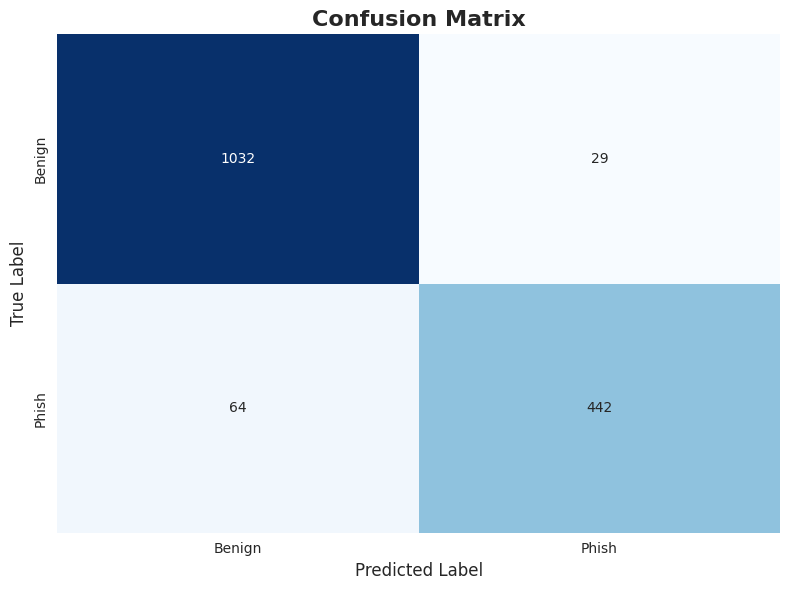

In [14]:
# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Benign', 'Phish'],
            yticklabels=['Benign', 'Phish'])
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

## 11. Save the Model

In [ ]:
# Save the trained model
model.save('phishing_detection_model.h5')
print("✓ Model saved as 'phishing_detection_model.h5'")

# Save tokenizer for future use
import pickle
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("✓ Tokenizer saved as 'tokenizer.pkl'")

# Save model configuration
import json
model_config = {
    'max_words': MAX_WORDS,
    'max_len': MAX_LEN,
    'embedding_dim': EMBEDDING_DIM,
    'lstm_units': LSTM_UNITS,
    'test_accuracy': float(test_accuracy),
    'test_precision': float(test_precision),
    'test_recall': float(test_recall),
    'test_f1': float(test_f1)
}

with open('model_config.json', 'w') as f:
    json.dump(model_config, f, indent=4)
print("✓ Model configuration saved as 'model_config.json'")

print("\n" + "=" * 60)
print("All files saved successfully!")
print("You can now use these files to make predictions on new URLs.")

✓ Model saved as 'phishing_detection_model.h5'
✓ Tokenizer saved as 'tokenizer.pkl'
✓ Model configuration saved as 'model_config.json'

All files saved successfully!
You can now use these files to make predictions on new URLs.
